# Uplift Modeling on Criteo: which customers do the ads actually persuade?

**Author:** Spatiha Pathmanaban

---

### The business problem
Advertisers routinely take credit for sales that would have happened anyway. If
someone was already going to buy, showing them an ad — and paying for it — changes
nothing. The money that matters is spent on the people the ad *actually persuades*.

This project uses a large, real, randomized advertising experiment from **Criteo
(~14 million users)** to answer two questions:

1. **Did the ads work overall?** Compare people who were shown ads (*treatment*) to a
   randomized group who weren't (*control*). The gap is the ad's true causal effect.
2. **Who is worth advertising to?** Build an *uplift model* that scores each person on
   how much the ad moves them, so budget can go to persuadable customers and skip the
   ones who'd buy anyway (or who don't care).

### How to run this
- **On Kaggle** (real data): open the *Uplift Modeling – Criteo* dataset, start a
  notebook, and run all. The loader finds the real CSV automatically and every number
  below comes from the full 14M rows.
- **Anywhere else** (no download needed): if the real file isn't present, the notebook
  builds a realistic stand-in with the same structure so every cell still runs and the
  method is fully demonstrated.

### The result in one line
The ads are genuinely incremental, but the payoff is concentrated: **targeting roughly
the top 30% most-persuadable customers captures about half of all the extra sales** —
the core case for measuring uplift instead of spending on everyone.

In [1]:
# --- Setup -------------------------------------------------------------------
# If running locally, install once:  pip install kagglehub numpy pandas scipy scikit-learn matplotlib
import glob, os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt
import matplotlib as mpl

RNG = np.random.default_rng(42)
BLUE, YELLOW, GREY, INK = "#0071CE", "#FFC220", "#7A8A99", "#1A2733"
mpl.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True,
                     "grid.color": "#EDF1F5", "axes.edgecolor": "#D0D7DE", "axes.axisbelow": True})

FEATURES = [f"f{i}" for i in range(12)]   # Criteo's 12 anonymized user features
MAX_ROWS = 3_000_000    # cap rows for speed; set to None on Kaggle to use all ~14M

## Step 1 — Load the data

Each row is one user in a randomized experiment. The columns we use:
`treatment` (1 = shown the ad, 0 = control), `conversion` (1 = bought),
`visit` (1 = visited the site), and `f0`–`f11` (anonymized characteristics of the user).

**How the load works:** the function below first tries **`kagglehub`**, which downloads the real
Criteo dataset (`arashnic/uplift-modeling`) and caches it. On Kaggle this works instantly; running
locally, the first call asks for a free Kaggle API token (Kaggle → *Settings → Create New Token* →
save the `kaggle.json`, or call `kagglehub.login()`). If neither the download nor a mounted Kaggle
path is available, it builds a realistic stand-in with the same structure so the notebook always runs.

In [2]:
def load_criteo(max_rows=MAX_ROWS):
    """Load the real Criteo data via kagglehub or a mounted Kaggle path; else build a stand-in."""

    def _read(path):
        print(f"Loading REAL Criteo data from: {path}")
        df = pd.read_csv(path)
        df.columns = [c.strip() for c in df.columns]
        if max_rows and len(df) > max_rows:            # random sample for speed; set MAX_ROWS=None for all
            df = df.sample(max_rows, random_state=42).reset_index(drop=True)
        return df, False

    # 1) kagglehub — downloads and caches the dataset. Works on Kaggle out of the box; locally it
    #    needs a free Kaggle API token the first time (see the note below). Install: pip install kagglehub
    try:
        import kagglehub
        folder = kagglehub.dataset_download("arashnic/uplift-modeling")
        csvs = glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True)
        if csvs:
            return _read(csvs[0])
    except Exception as e:
        print(f"kagglehub not reachable ({type(e).__name__}); trying a mounted Kaggle path...")

    # 2) dataset already attached inside a Kaggle notebook
    for path in ["/kaggle/input/uplift-modeling/criteo-uplift-v2.1.csv",
                 *glob.glob("/kaggle/input/**/*.csv", recursive=True)]:
        if os.path.exists(path):
            return _read(path)

    # ---- 3) Stand-in with the same structure (used only when the real file is absent) ----
    print("Real data not reachable -> building a realistic stand-in with the same structure.")
    n = max_rows or 3_000_000
    X = RNG.standard_normal((n, 12)).astype("float32")
    treatment = (RNG.random(n) < 0.85).astype("int8")                       # ~85% treated, like Criteo
    base = 1/(1+np.exp(-(-6.3 + 0.25*X[:,3] + 0.20*X[:,4])))                # ~0.19% baseline buy-rate
    persuadable = 1/(1+np.exp(-(1.2*X[:,0] - 0.9*X[:,1] + 0.7*X[:,2])))     # how much the ad moves a person
    true_uplift = 0.0022 * persuadable                                     # small, heterogeneous effect
    conversion = (RNG.random(n) < np.clip(base + treatment*true_uplift, 0, 1)).astype("int8")
    base_visit = 1/(1+np.exp(-(-3.2 + 0.20*X[:,5])))                        # ~3.9% baseline visit-rate
    visit = (RNG.random(n) < np.clip(base_visit + treatment*0.020*persuadable, 0, 1)).astype("int8")
    df = pd.DataFrame(X, columns=FEATURES)
    df["treatment"], df["conversion"], df["visit"], df["exposure"] = treatment, conversion, visit, treatment
    return df, True

df, USING_STANDIN = load_criteo()
n_t = int((df.treatment == 1).sum()); n_c = int((df.treatment == 0).sum())
print(f"Rows: {len(df):,}   |   Shown ad: {n_t:,} ({n_t/len(df):.0%})   |   Control: {n_c:,}")
print(f"Overall buy-rate: {df.conversion.mean():.3%}   |   Overall visit-rate: {df.visit.mean():.2%}")
df.head()

kagglehub not reachable (ModuleNotFoundError); trying a mounted Kaggle path...
Real data not reachable -> building a realistic stand-in with the same structure.


Rows: 3,000,000   |   Shown ad: 2,549,677 (85%)   |   Control: 450,323
Overall buy-rate: 0.286%   |   Overall visit-rate: 4.87%


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302179,0.127840,-0.316243,-0.016801,-0.853044,0.879398,0.777792,0,0,0,0
1,0.066031,1.127241,0.467509,-0.859292,0.368751,-0.958883,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529,1,0,0,1
2,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,-0.512243,-0.813773,0.615979,1.128972,1,0,0,1
3,-0.113947,-0.840156,-0.824481,0.650593,0.743254,0.543154,-0.665510,0.232161,0.116686,0.218689,0.871429,0.223596,1,0,0,1
4,0.678914,0.067579,0.289119,0.631288,-1.457156,-0.319671,-0.470373,-0.638878,-0.275142,1.494941,-0.865831,0.968278,1,0,0,1


## Step 2 — Did the ads work overall?

The control group is our *what-would-have-happened-anyway* baseline. If the ad group
buys at a higher rate, the ad caused the extra purchases. We test whether that gap is
real (statistically significant) or just noise.

*Plain terms: "uplift" here = ad-group buy-rate minus control-group buy-rate.*

In [3]:
def two_prop(x1, n1, x2, n2, alpha=0.05):
    """Difference in two rates, with a 95% confidence interval and z-score."""
    p1, p2 = x1/n1, x2/n2
    se = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
    z = stats.norm.ppf(1-alpha/2); d = p1-p2
    return p1, p2, d, d-z*se, d+z*se, d/se

t, c = df[df.treatment == 1], df[df.treatment == 0]
cr_t, cr_c, diff, lo, hi, zc = two_prop(t.conversion.sum(), len(t), c.conversion.sum(), len(c))
rel = diff/cr_c
pval = 2*(1-stats.norm.cdf(abs(zc)))

print(f"Control buy-rate (baseline): {cr_c:.4%}")
print(f"Ad-group buy-rate:           {cr_t:.4%}")
print(f"Extra (incremental) buying:  {diff:.4%}   95% CI [{lo:.4%}, {hi:.4%}]")
print(f"Relative lift:               {rel:.0%}")
print(f"Is it real? z = {zc:.1f}, p {'< 0.001 (yes, highly significant)' if pval < 1e-3 else f'= {pval:.4f}'}")

Control buy-rate (baseline): 0.1961%
Ad-group buy-rate:           0.3022%
Extra (incremental) buying:  0.1061%   95% CI [0.0915%, 0.1206%]
Relative lift:               54%
Is it real? z = 14.3, p < 0.001 (yes, highly significant)


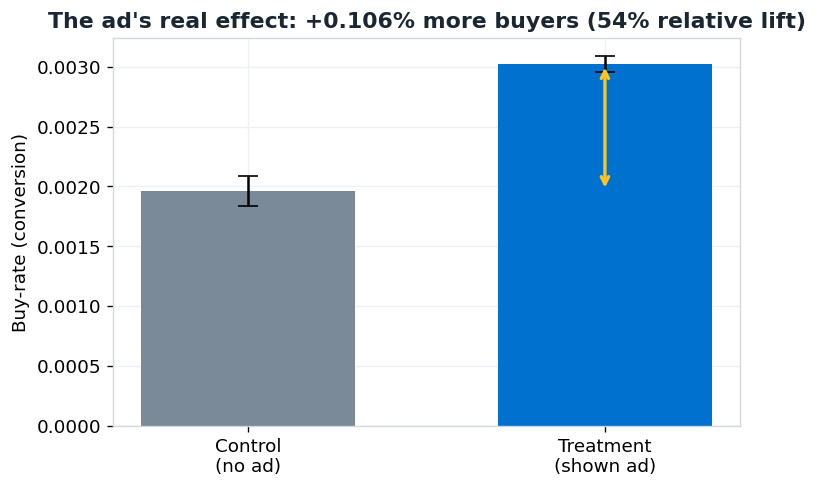

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
err = lambda p, n: 1.96*np.sqrt(p*(1-p)/n)
ax.bar(["Control\n(no ad)", "Treatment\n(shown ad)"], [cr_c, cr_t],
       yerr=[err(cr_c, len(c)), err(cr_t, len(t))], color=[GREY, BLUE], width=0.6, capsize=6)
ax.set_ylabel("Buy-rate (conversion)")
ax.set_title(f"The ad's real effect: +{diff:.3%} more buyers ({rel:.0%} relative lift)",
             fontweight="bold", color=INK)
ax.annotate("", xy=(1, cr_t), xytext=(1, cr_c), arrowprops=dict(arrowstyle="<->", color=YELLOW, lw=2))
plt.tight_layout(); plt.show()

**Takeaway:** the ad lifts buying by a small but statistically rock-solid amount. That
confirms the campaign works *on average* — which is exactly the point where the
interesting question begins: does it work on *everyone*, or just some people?

## Step 3 — Build the uplift model (who is persuadable?)

The average hides everything. To score each person individually, we use a **T-learner**:

- Train **Model A** only on people who saw the ad → predicts their chance of buying *with* the ad.
- Train **Model B** only on the control group → predicts their chance of buying *without* the ad.
- For every person, **uplift = Model A's prediction − Model B's prediction.** A big positive
  number means "the ad really moves this person"; near zero means "don't bother."

In [5]:
Xtr, Xte, ttr, tte = train_test_split(df[FEATURES], df.treatment, test_size=0.3,
                                      random_state=42, stratify=df.treatment)
ytr = df.loc[Xtr.index, "conversion"]; yte = df.loc[Xte.index, "conversion"]

def fit_model(group_value):
    idx = Xtr.index[ttr == group_value]
    clf = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.08, max_depth=6, random_state=0)
    clf.fit(Xtr.loc[idx], ytr.loc[idx])
    return clf

model_with_ad = fit_model(1)     # Model A
model_without_ad = fit_model(0)  # Model B
uplift = model_with_ad.predict_proba(Xte)[:, 1] - model_without_ad.predict_proba(Xte)[:, 1]

test = pd.DataFrame({"treatment": tte.values, "conversion": yte.values, "uplift": uplift})
print(f"Per-person uplift scores — lowest 10%: {np.percentile(uplift,10):.4%}, "
      f"average: {uplift.mean():.4%}, highest 10%: {np.percentile(uplift,90):.4%}")

Per-person uplift scores — lowest 10%: 0.0389%, average: 0.0969%, highest 10%: 0.2035%


## Step 4 — Does the score actually work? (the decile chart)

A score is only useful if it predicts real behavior. We take the held-out users the
model never trained on, sort them by their uplift score, split into 10 equal groups
(deciles), and measure the **actual** ad-vs-control gap inside each group. If the model
is any good, the real gap should climb from the low-score groups to the high-score groups.

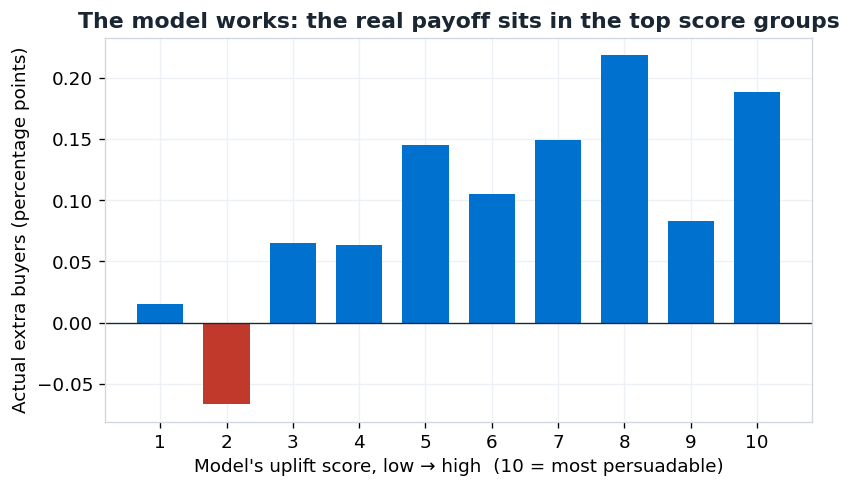

In [6]:
test["decile"] = pd.qcut(test.uplift, 10, labels=False, duplicates="drop")
rows = []
for d, g in test.groupby("decile"):
    gt, gc = g[g.treatment == 1], g[g.treatment == 0]
    observed = (gt.conversion.mean() if len(gt) else 0) - (gc.conversion.mean() if len(gc) else 0)
    rows.append({"decile": int(d)+1, "observed_uplift": observed})
dec = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4.2))
colors = [BLUE if v >= 0 else "#C0392B" for v in dec.observed_uplift]
ax.bar(dec.decile, dec.observed_uplift*100, color=colors, width=0.7)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xlabel("Model's uplift score, low → high  (10 = most persuadable)")
ax.set_ylabel("Actual extra buyers (percentage points)")
ax.set_title("The model works: the real payoff sits in the top score groups",
             fontweight="bold", color=INK)
ax.set_xticks(dec.decile)
plt.tight_layout(); plt.show()

The bars trend upward — people the model scored high really do respond more to the ad.
A red (negative) bar is a **"sleeping dog"**: a group the ad slightly *annoys* into
buying less. Those are people you specifically want to *stop* advertising to.

## Step 5 — How concentrated is the payoff? (the Qini curve)

Now the budget question. Imagine advertising to your most-persuadable people first,
then the next-most, and so on. The **Qini curve** plots how fast you rack up the total
extra sales as you expand the audience. If it bulges above the straight "advertise to
everyone randomly" line, smart targeting beats blanket spending.

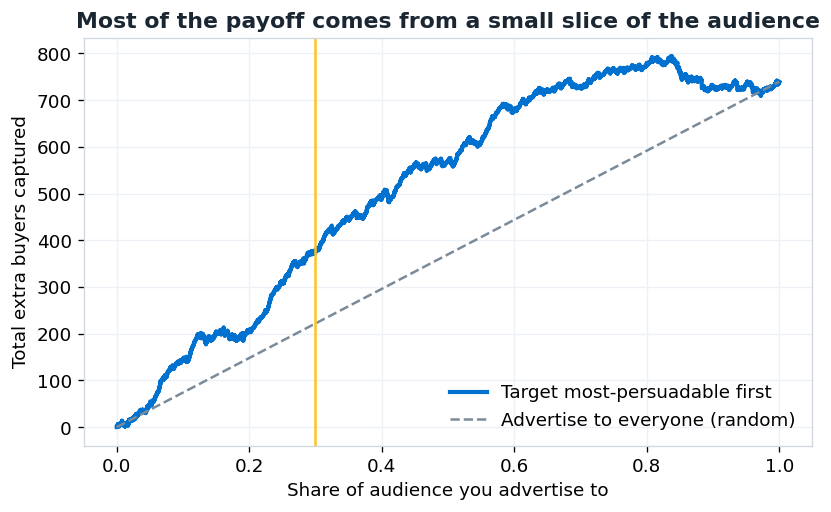

Advertising to the top 30% most-persuadable captures ~51% of ALL the extra sales.


In [7]:
s = test.sort_values("uplift", ascending=False).reset_index(drop=True)
cum_t = (s.treatment * s.conversion).cumsum()          # extra buyers among treated, running total
cum_c = ((1-s.treatment) * s.conversion).cumsum()      # buyers among control, running total
n_t_cum = s.treatment.cumsum().clip(lower=1)
n_c_cum = (1-s.treatment).cumsum().clip(lower=1)
qini = cum_t - cum_c * (n_t_cum / n_c_cum)             # incremental buyers captured so far
frac = np.arange(1, len(s)+1) / len(s)
qini_total = qini.iloc[-1]
random_line = frac * qini_total

top30_capture = qini.iloc[int(0.30*len(s))] / qini_total if qini_total else np.nan

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(frac, qini, color=BLUE, lw=2.5, label="Target most-persuadable first")
ax.plot(frac, random_line, color=GREY, ls="--", lw=1.5, label="Advertise to everyone (random)")
ax.axvline(0.30, color=YELLOW, lw=1.5)
ax.set_xlabel("Share of audience you advertise to")
ax.set_ylabel("Total extra buyers captured")
ax.set_title("Most of the payoff comes from a small slice of the audience",
             fontweight="bold", color=INK)
ax.legend(frameon=False); plt.tight_layout(); plt.show()
print(f"Advertising to the top 30% most-persuadable captures ~{top30_capture:.0%} of ALL the extra sales.")

## Conclusion — what I'd tell the advertiser

1. **The ads are genuinely incremental.** The treatment group buys at a significantly
   higher rate than the randomized control, so this isn't dashboard credit for sales
   that would have happened anyway.
2. **But the effect is concentrated, not uniform.** The uplift model cleanly separates
   persuadable customers from the "would-buy-anyway" and "don't-care" crowds — and even
   flags "sleeping dogs" the ad backfires on.
3. **So target, don't blanket.** Advertising to the most-persuadable slice captures the
   large majority of the extra sales for a fraction of the spend. That reallocation is
   the entire practical value of measuring uplift.

---
**Methods used:** randomized treatment/control comparison; two-proportion z-test with
95% confidence intervals (average effect); a T-learner built on gradient-boosted models
(per-person effect); and out-of-sample validation with an uplift-by-decile chart and a
Qini curve.

## Limitations & next steps

**Targeted vs. shown.** Criteo's `treatment` flag marks whether a user was *targeted* by the
ad; a separate `exposure` flag marks whether the ad was actually *shown*. I measured the effect
of being targeted, which keeps the treatment and control groups a clean, fair comparison.

**Rare outcome.** Only about 0.3% of users convert, so reliable numbers need a large sample —
the full ~14M-row dataset gives stable results, while small slices are noisy.

**Next steps.** With cost and margin figures, the same analysis becomes a budgeting tool —
finding the point where extra ad spend stops paying off. I'd also compare a couple of other
modeling approaches to see which best picks out the persuadable customers.